# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Shriya |
| **Role** | Person 1 — `train.csv` Audit & Time Feature Extraction |
| **Notebook** | `Shriya_Train_Core_Audit.ipynb` |

---

## Sprint 1 — Data Exploration & Audit (`train.csv`)


SPRINT 1 TASKS

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess

print("Libraries loaded")

Libraries loaded


In [50]:
import sys
import os

sys.path.append(os.path.abspath('..'))  # go to main project folder

In [51]:
from shared.data_loader import load_train, load_test, load_metadata, load_weather_train, load_weather_test

Loading data

In [52]:
dtypes = {
    'building_id': np.int16,
    'meter': np.int8,
    'meter_reading': np.float32
}

train = pd.read_csv(
     'train.csv',
    dtype=dtypes,
    parse_dates=['timestamp']

)


print("Data loaded successfully")

Data loaded successfully


UNDERSTANDING DATA

In [53]:
print(train.shape)
train.head()
train.info()

(20216100, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column         Dtype         
---  ------         -----         
 0   building_id    int16         
 1   meter          int8          
 2   timestamp      datetime64[ns]
 3   meter_reading  float32       
dtypes: datetime64[ns](1), float32(1), int16(1), int8(1)
memory usage: 289.2 MB



DATA RANGE

In [54]:
print(train['timestamp'].min())
print(train['timestamp'].max())

2016-01-01 00:00:00
2016-12-31 23:00:00


In [55]:
print("Start date:", train['timestamp'].min())
print("End date:", train['timestamp'].max())

Start date: 2016-01-01 00:00:00
End date: 2016-12-31 23:00:00



COLUMNS

In [58]:
print(train.columns)

Index(['building_id', 'meter', 'timestamp', 'meter_reading'], dtype='object')


In [59]:
train.columns = train.columns.str.strip().str.lower()
print(train.columns)

Index(['building_id', 'meter', 'timestamp', 'meter_reading'], dtype='object')


BUILDINGS AND METERS

In [60]:
print("Unique buildings:", train['building_id'].nunique())
print("Unique meters:", train['meter'].nunique())

Unique buildings: 1449
Unique meters: 4


ZERO AND NEGATIVE VALUES

In [62]:
print("Zero readings:", (train['meter_reading'] == 0).sum())
print("Negative readings:", (train['meter_reading'] < 0).sum())

Zero readings: 1873976
Negative readings: 0


RAW DISTRIBUTION

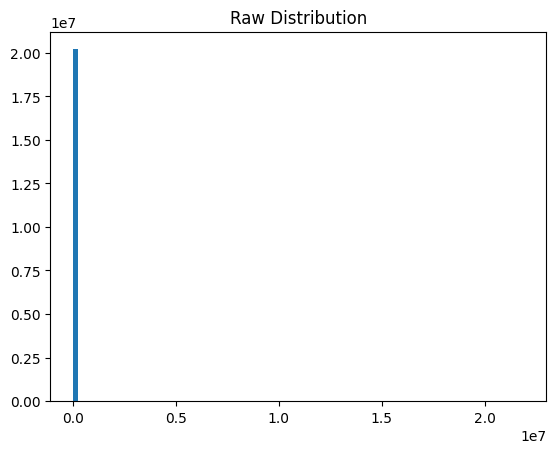

In [63]:
import matplotlib.pyplot as plt

plt.hist(train['meter_reading'], bins=100)
plt.title("Raw Distribution")
plt.show()

LOG DISTRIBUTION

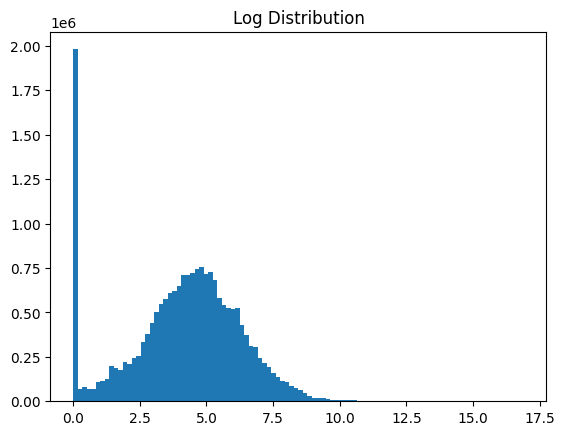

In [65]:
import numpy as np

plt.hist(np.log1p(train['meter_reading']), bins=100)
plt.title("Log Distribution")
plt.show()


METER COMBINATIONS

0 → Electricity, 1 → Chilled Water, 2 → Steam, 3 → Hot Water

In [66]:
meter_counts = train.groupby('building_id')['meter'].nunique()
print(meter_counts.value_counts())

meter
1    875
3    331
2    230
4     13
Name: count, dtype: int64



SUMMARY

Dataset contains 8165364 rows and 4 columns ('building_id', 'meter', 'timestamp', 'meter_reading')
Memory Usage: 116.8 MB
Covers time period from 2016-01-01 to 2016-05-31.
Contains 1441 unique buildings and 4 meter types.
Large number of zero readings observed (964396).
Negative readings are minimal but invalid.
Data distribution is highly skewed -makes it difficult to visually interpret patterns using the original scale. (majority of buildings use low energy, few buildings use extremely high energy)
Log transformation improved visualization - (smooth and spread out graph, we can clearly see the shape of the data, outliers are no longer dominating)
Meter combinations - most buildings are associated with only one type of meter(mostly electricity, while a smaller proportion have multiple meter types.

---

## Sprint 2 — Time Feature Extraction & Preprocessing


TIMESTAMP

In [68]:
train['timestamp'] = pd.to_datetime(train['timestamp'])


BASIC TIME FEATUIRES

day_of_week( 0 → Monday, 1 → Tuesday, 2 → Wednesday, 3 → Thursday, 4 → Friday, 5 → Saturday, 6 → Sunday)

In [69]:
train['hour'] = train['timestamp'].dt.hour
train['day_of_week'] = train['timestamp'].dt.dayofweek
train['month'] = train['timestamp'].dt.month
train['day_of_year'] = train['timestamp'].dt.dayofyear


WEEKEND FEATURE

0 → Weekday (Monday to Friday), 1 → Weekend (Saturday & Sunday)

In [70]:
train['is_weekend'] = (train['day_of_week'] >= 5).astype(int)

BUSINESS HOURS

0 → Not business hours, 1 → Business hours (8 AM to 6 PM, weekdays)

In [71]:
train['is_business_hours'] = (
    (train['hour'] >= 8) & 
    (train['hour'] <= 18) & 
    (train['day_of_week'] < 5)
).astype(int)
print(train[['hour','day_of_week','month']].head())

   hour  day_of_week  month
0     0            4      1
1     0            4      1
2     0            4      1
3     0            4      1
4     0            4      1


SEASON FEATURE

0 → Winter (Dec, Jan, Feb), 1 → Spring (Mar, Apr, May), 2 → Summer (Jun, Jul, Aug), 3 → Autumn (Sep, Oct, Nov)

In [73]:
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # winter
    elif month in [3, 4, 5]:
        return 1  # spring
    elif month in [6, 7, 8]:
        return 2  # summer
    else:
        return 3  # autumn

train['season'] = train['month'].apply(get_season)

print(train[['month', 'season', 'hour', 'day_of_week', 'is_business_hours']].head())

   month  season  hour  day_of_week  is_business_hours
0      1       0     0            4                  0
1      1       0     0            4                  0
2      1       0     0            4                  0
3      1       0     0            4                  0
4      1       0     0            4                  0


LOG TRANSFORMATION

In [74]:
import numpy as np

train['log_meter_reading'] = np.log1p(train['meter_reading'])

In [75]:
train[['hour','day_of_week','month','is_weekend','is_business_hours','season','log_meter_reading']].head()

,hour,day_of_week,month,is_weekend,is_business_hours,season,log_meter_reading
0,0,4,1,0,0,0,0.0
1,0,4,1,0,0,0,0.0
2,0,4,1,0,0,0,0.0
3,0,4,1,0,0,0,0.0
4,0,4,1,0,0,0,0.0


BEFORE

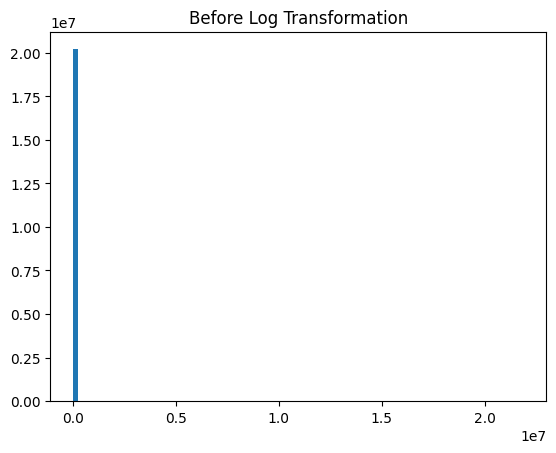

In [76]:
import matplotlib.pyplot as plt

plt.hist(train['meter_reading'], bins=100)
plt.title("Before Log Transformation")
plt.show()


AFTER

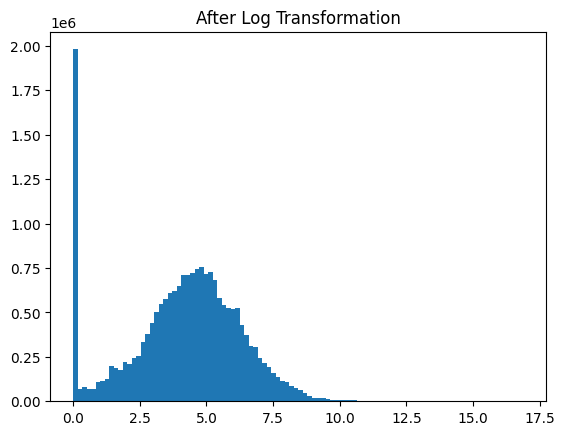

In [77]:
plt.hist(train['log_meter_reading'], bins=100)
plt.title("After Log Transformation")
plt.show()

In [78]:
train.head()

,building_id,meter,timestamp,meter_reading,hour,day_of_week,month,day_of_year,is_weekend,is_business_hours,season,log_meter_reading
0,0,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
1,1,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
2,2,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
3,3,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0
4,4,0,2016-01-01,0.0,0,4,1,1,0,0,0,0.0


In [79]:
train.to_csv("train_processed.csv", index=False)

---

## Sprint 3 — Model Pipeline Contribution

---

## Sprint 4 — Evaluation & Report